# VMT Reduction Likelihood Analysis

The purpose of this script is to define a set of rules that classify which trips in the TBI could, with high likelihood, switch to another mode. These trips will be a subset of the feasible trips and will satisfy more stringent conditions than the feasibility analysis, as even if a switch is feasible, that does not mean a person is likely to do it. The result of this analysis will be a set of binary flags attached to each TBI record where the mode is car:

    likely_walk_shift    - it is feasible for the trip to switch to walk
    likely_bike_shift    - it is feasible for the trip to switch to bike
    likely_transit_shift - it is feasible for the trip to switch to transit
    likely_shift         - it is feasible for the trip to switch to any non-car mode

In all cases, the flag starts as 1 (feasible) and we set it to infeasible if it violates one or more of our rules.  Even though our interst is in understanding which car trips could switch to another mode, we code this flag for all modes.  This way, we can see how existing trips on that mode violate the feasibility rules.  In general, we aim to follow the "95% rule" such that 95% of trips that currently use that mode meet the feasibility condition.  Therefore, about 5% of trips will violate our own rules.  This is ok, because these trips are the most dedicated users of that mode, and new users will likely be less dedicated.  

The list below shows several of the factors we wish to test.  

### Definition of what is a likely mode shift

- duration differences (15 minute threshold to start with w.r.t to the car trip)
- disability -- only transit is likely
- timing without any overlaps in trips
- weather for walking (no walking when there is rain)
- weather for biking (no biking when there is rain)
- number of transfers (0 is likely)
- temperature > 12 degrees (walking and biking)
- light outside (walking and biking)
- shopping purpose/escort purpose should only be car

- any lts 3 or 4 distance -- biking unlikely

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
import math
import keyring
import itertools
from ast import literal_eval

In [3]:
from suncalc import get_position, get_times
from datetime import datetime as dt
import pytz

In [4]:
# This is used to avoid hard-coding directories. 
# To set the directory, use the command prompt or a notebook you don't check in.  run:
# import keyring
# keyring.set_password("msp", "vmt_reduction_dir", <directory>)

# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [5]:
raw = pd.read_csv("feasibility_out.csv")

C:\Users\yianz\AppData\Local\Temp\ipykernel_22588\2786893731.py:1: DtypeWarning: Columns (34,35,36,53,65,66,67,68,69,70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv("feasibility_out.csv")


In [6]:
# only consider trips that are a feasible shift; feasibility is a necessity for a trip being likely
df = raw.loc[raw["feasible_shift"], :].copy()

In [7]:
# reading in weather data
# https://www.ncei.noaa.gov/pub/data/ghcn/daily/
weather = pd.read_csv("extra_data/USW00014922.csv")
weather = weather[["Date", "Measurement", "Value"]]
weather = weather.pivot(index="Date", columns="Measurement", values="Value")
weather

C:\Users\yianz\AppData\Local\Temp\ipykernel_22588\2067923688.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv("extra_data/USW00014922.csv")


Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT16,WT17,WT18,WT19,WT21,WT22,WV01,WV03,WV07,WV20
Date,,,,,,,,,,,,,,,,,,,,,
19380409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20230311,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230312,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230313,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
weather["year"] = weather.index.astype(str).str[0:4]
weather["month"] = weather.index.astype(str).str[4:6]
weather["day"] = weather.index.astype(str).str[6:8]
weather["date"] = weather["year"] + "-" + weather["month"] + "-" + weather["day"]
weather = weather.set_index("date")
weather

Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT19,WT21,WT22,WV01,WV03,WV07,WV20,year,month,day
date,,,,,,,,,,,,,,,,,,,,,
1938-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,09
1938-04-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,10
1938-04-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,11
1938-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,12
1938-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-11,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,11
2023-03-12,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,12
2023-03-13,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,13


As before, there are also configurable thresholds to tweak the likelihood analysis thresholds and figures shown in this notebook.

In [9]:
#| echo: true
MAX_PROBABLE_DIST = 15
MAX_PROBABLE_DIST_PCT = 0.5
MAX_PROBABLE_RAIN = 0
MIN_PROBABLE_TEMPERATURE = 12
MIN_PROBABLE_TEMPERATURE_PCT = 0.5
MAX_PROBABLE_TRANFERS = 0
MAX_HIGH_LTS_DIST_BIKE = 0
MAX_HIGH_LTS_DIST_BIKE_PCT = 0.5

unlikely_purposes = ["Escort", "Shop"]

As before, all feasible trips can be considered likely to switch to an alternative mode at the beginning. 

In [10]:
#| echo: true
# everything is feasible initially
df['likely_walk_shift'] = True
df['likely_bike_shift'] = True
df['likely_transit_shift'] = True
df['likely_shift'] = True

In [11]:
#| echo: true
# omit schools bus and taxi/ridehail/carshare -- very different from other modes
valid_modes = [("Car","distance"), 
               ("Bike/Scooter","distance"), 
               ("Walk","distance"), 
               ("Transit","distance")]

In [12]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [13]:
def plot_mode_density(df: pd.DataFrame, modes=valid_modes, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for m in modes: # cycle through all modes
        mode = m[0]
        column = m[1]
        label = mode + ' ' + column
        
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[column]), ax=ax, stat="density", kde=True, label=label, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[column]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot        
        plt.legend()
    return fig, ax

In [14]:
def show_summaries(df: pd.DataFrame, modes=valid_modes, percentile=[0.95]): # show normal summaries for each mode side by side
    res = []
    labels = []
    if type(percentile) != type([]):
        percentile = [percentile]
    p = [0.25, 0.5, 0.75]
    p += percentile
    p = list(set(p))
    for m in modes:        
        mode = m[0]
        column = m[1]
        labels.append(mode + ' ' + column)
        
        group = df[df["mode"] == mode]
        res.append(group[column].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = labels
    return x

In [15]:
def plot_multi_barplot(df: pd.DataFrame, x: str, y: str, figsize=(7, 5), order=None):
    # plot normalized bar plot of the values in each mode side by side
    fig, ax = plt.subplots(figsize=figsize)
    if y == "mode": 
        df = df[df["mode"].isin([x[0] for x in valid_modes])]
    (df
     .groupby(y)[x]
     .value_counts(normalize=True)
     .mul(100)
     .rename("percent")
     .reset_index()
     .pipe((sns.barplot, "data"), x=x, y="percent", hue=y, ax=ax, order=order)
    )
    
    return fig, ax

## 1. Difference between durations of alternative mode and car mode > X minutes

Even if switching from a car mode to a non-car mode is considered feasible in terms of the factors discussed previously, a person may not be likely to choose to do so if the time difference is too great. Here we consider a 15 minute maximum between a non-car mode and car mode as a feasible shift.

### 1a. Bike duration difference (later, convert this cutoff to one based on the data)

Below, a distribution of the difference between observed car trips durations on a car mode versus a biking alternative. This distribution is overlayed on the inverse--the difference between car durations for observed bike trips and their corresponding observed biking durations. 

The specified percentile is also shown with vertical lines. The percentiles are flipped here as the left represents more un-ideal conditions, which makes the consideration of these flipped percentiles more meaningful in gauging trip shift likelihood. 

If the specified percentile is used as a criteria, then any of the orange trips to the left of the blue line could likely shift to biking.

In [16]:
df["observed_minus_bike"] = df["duration"] - df["bike_duration_seconds"] / 60
df["car_minus_observed"] = df["car_duration_seconds"] / 60 - df["duration"]

Text(0.5, 1.0, 'Comparison of distribution of bike trip car durations minus observed bike and observed car trip durations minus rerouted bike')

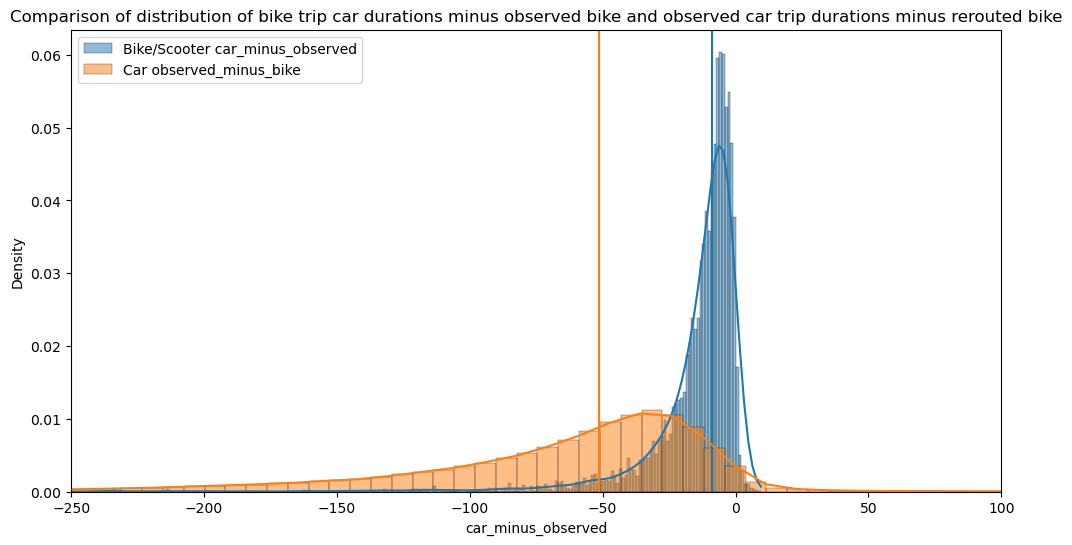

In [17]:
#| output: true

fig, ax = plot_mode_density(df, [('Bike/Scooter','car_minus_observed'), ('Car','observed_minus_bike')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of bike trip car durations minus observed bike and observed car trip durations minus rerouted bike")

Below we can see the summary statistics for the above distribution. Nothing is too shocking, with the statistics reflecting what was seen with the graph.

In [18]:
#| output: true

show_summaries(df, modes= [('Bike/Scooter','car_minus_observed'), ('Car','observed_minus_bike')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Bike/Scooter car_minus_observed,Car observed_minus_bike
count,6830.000000,202874.000000
mean,-14.975196,-67.463724
std,21.908083,62.403613
min,-304.336667,-1499.788333
25%,-17.223333,-91.931250
50%,-8.888333,-51.450833
75%,-4.418333,-27.348333
max,9.538333,849.526667


In [19]:
df["duration_minus_bike"] = df["duration"] - df["bike_duration_seconds"] / 60
df[df["mode"] == "Car"]["duration_minus_bike"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    202874.000000
mean        -67.463724
std          62.403613
min       -1499.788333
25%         -91.931250
50%         -51.450833
75%         -27.348333
80%         -22.668333
85%         -17.723333
90%         -11.855000
95%          -3.455000
max         849.526667
Name: duration_minus_bike, dtype: float64

By adding a condition for the maximum duration difference between biking and car duration to account for the increases in duration when shifting to biking and the corresponding loss of utility, we reduce the percentage of car trips that can likely shift to biking substantially.

In [20]:
#| output: true

# require all bike trips to occur via 250 meters or less on lts 3/4 roads
df["likely_biking_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["duration_minus_bike"] < -1 * MAX_PROBABLE_DIST, 'likely_bike_shift'] = False
df.loc[df["duration_minus_bike"] < -1 * MAX_PROBABLE_DIST, 'likely_biking_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  100.0  percent of car trips could shift to biking.
After constraint  12.520579275806659  percent of car trips could shift to biking.


### 1b. Walk duration difference (later, convert this cutoff to one based on the data)

Below, a distribution of the difference between observed car trips durations on a car mode versus a walking alternative. This distribution is overlayed on the inverse--the difference between car durations for observed walking trips and their corresponding observed biking durations. 

The specified percentile is also shown with vertical lines. The percentiles are flipped here as the left represents more un-ideal conditions, which makes the consideration of these flipped percentiles more meaningful in gauging trip shift likelihood. 

If the specified percentile is used as a criteria, then any of the orange trips to the left of the blue line could likely shift to walking. This logic is essentially the same that was explained in the biking duration difference section.

In [21]:
df["observed_minus_walk"] = df["duration"] - df["walk_duration_seconds"] / 60

Text(0.5, 1.0, 'Comparison of distribution of walk trip car durations minus observed walk and observed car trip durations minus rerouted walk')

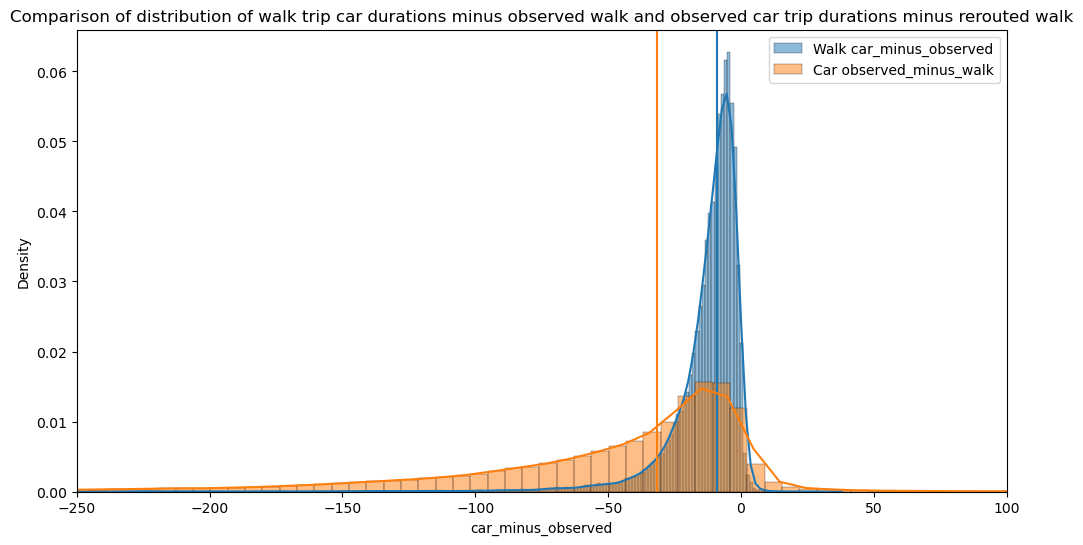

In [22]:
#| output: true

fig, ax = plot_mode_density(df, [('Walk','car_minus_observed'), ('Car','observed_minus_walk')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of walk trip car durations minus observed walk and observed car trip durations minus rerouted walk")

The corresponding summary statistics for the above graph are shown below.

In [23]:
#| output: true

show_summaries(df, modes=[('Walk','car_minus_observed'), ('Car','observed_minus_walk')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Walk car_minus_observed,Car observed_minus_walk
count,46488.000000,202874.000000
mean,-13.372701,-51.754845
std,18.011349,63.913270
min,-321.343333,-1106.426667
25%,-16.047083,-73.313333
50%,-9.056667,-31.442500
75%,-4.726667,-11.698333
max,37.965000,850.415000


In [24]:
df["duration_minus_walk"] = df["duration"] - df["walk_duration_seconds"] / 60
df[df["mode"] == "Car"]["duration_minus_walk"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    202874.000000
mean        -51.754845
std          63.913270
min       -1106.426667
25%         -73.313333
50%         -31.442500
75%         -11.698333
80%          -8.548333
85%          -5.276667
90%          -1.883333
95%           2.895000
max         850.415000
Name: duration_minus_walk, dtype: float64

By imposing a restriction on the maximum duration that a walk shift can slow down what was originally a car trip, we restrict the percent of trips that can likely shift to walking from driving, although this is to a lesser degree than was seen with walking.

In [25]:
#| output: true

df["likely_walking_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

df.loc[df["duration_minus_walk"] < -1 * MAX_PROBABLE_DIST, 'likely_walk_shift'] = False
df.loc[df["duration_minus_walk"] < -1 * MAX_PROBABLE_DIST, 'likely_walking_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  100.0  percent of car trips could shift to walking.
After constraint  30.223192720604906  percent of car trips could shift to walking.


### 1c. Transit duration difference (later, convert this cutoff to one based on the data)

In [26]:
df["observed_minus_transit"] = df["duration"] - df["transit_duration"]

Below, a comparison of the distributions for observed transit trip car minus tranist duration and observed car trip car minus transit duration (rerouting as needed) can be seen. This is analagous with the previous two graphs shown in sections 1a and 1b.

Interestingly, here we observe a deviation from the graphs in the previous section, with observed transit trips having higher duration differences than their corresponding cars. As such, with a duration difference restriction, a good amount of car trips can still likely shift to transit.

There also appear to be more car trips that could actually be faster when taken on transit here. This could be due to the more stringent restrictions placed upon transit trips in the feasibility analysis section.

In [ ]:
# TODO: switch to both rerouted for duration difference
# clarify language (% of trips that are most likely to switch)
# eventually get to who are these people, disaggregate the results
    # re-aggregate by certain regions to see differential effects
    # add details to reporting
    # community area layer for aggregation
    # aggregate by groups as well -- race, gender, income a bit
        # family structure (single adults, adults with no kids, single parents, etc.), age, disability status (move from constraint to category)
    # mode most likely to switch to (possibly by trip length)
# add vmt back to probable analysis


Text(0.5, 1.0, 'Comparison of distribution of transit trip car durations minus observed transit and observed car trip durations minus rerouted transit')

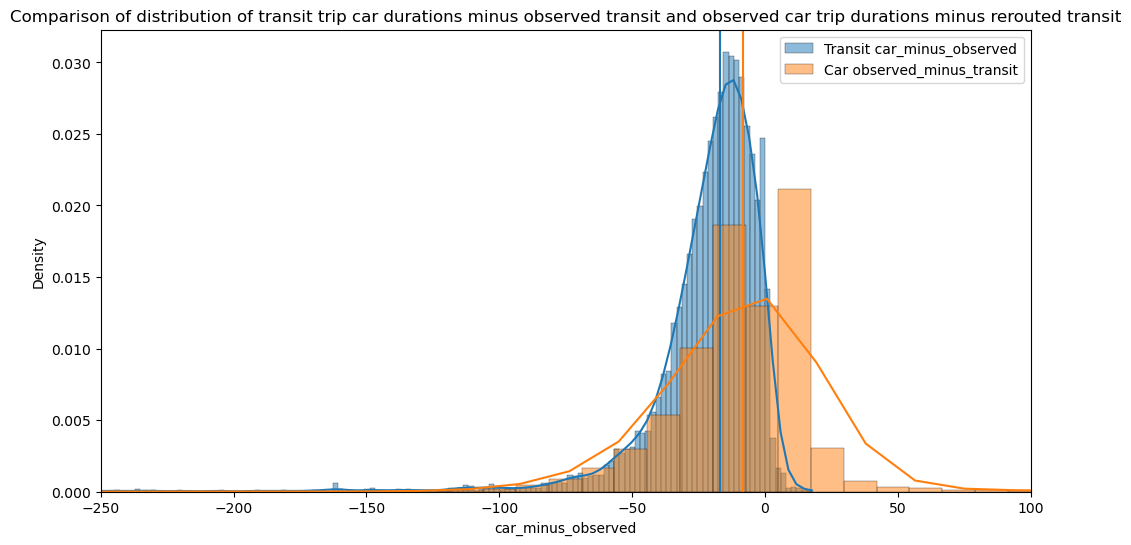

In [27]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','car_minus_observed'), ('Car','observed_minus_transit')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of transit trip car durations minus observed transit and observed car trip durations minus rerouted transit")

The summary statistics for this graph can be found below.

In [28]:
#| output: true

show_summaries(df, modes=[('Transit','car_minus_observed'), ('Car','observed_minus_transit')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Transit car_minus_observed,Car observed_minus_transit
count,8995.000000,202874.000000
mean,-21.880713,-38.205700
std,24.713411,218.794219
min,-570.000000,-2843.300000
25%,-28.058333,-22.516667
50%,-16.901667,-8.200000
75%,-8.594167,7.500000
max,17.686667,855.800000


In [29]:
df["duration_minus_transit"] = df["duration"] - df["transit_duration"]
df[df["mode"] == "Car"]["duration_minus_transit"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    202874.000000
mean        -38.205700
std         218.794219
min       -2843.300000
25%         -22.516667
50%          -8.200000
75%           7.500000
80%           9.200000
85%          11.100000
90%          14.100000
95%          19.600000
max         855.800000
Name: duration_minus_transit, dtype: float64

In [30]:
#| output: true

df["likely_transit_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["duration_minus_transit"] < -1 * MAX_PROBABLE_DIST, 'likely_transit_shift'] = False
df.loc[df["duration_minus_transit"] < -1 * MAX_PROBABLE_DIST, 'likely_transit_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  100.0  percent of car trips could shift to biking.
After constraint  63.81990792314441  percent of car trips could shift to biking.


## 2. Timing

As discussed in the feasibility analysis, a trip was considered feasible timing-wise if the actor could work around all discretionary trips (possibly skipping them and doing them another time) to manage to reach all non-negotiable, non-discretionary trips. However, it is not necessarily the case that the actor would be likely to embark on a trip if they needed to abandon some of their daily activities like shopping or social visits. 

As an example, consider a daily activity pattern consisting of going from home to work, from work to shop, and finally, from shopping back to home. A feasible trip would allow the shoppign trip to be skipped (put off for another time), while a likely trip would facilitate going on the shopping trip still.

Therefore, we consider a trip likely if, even with the duration increases that come with switching to non-car modes, the daily acitivies can still be done without any overlaps/need to skip any of them to make to the next.

In [31]:
#| echo: true

fixed_purposes = ["Work", "Work-related", "Escort", "School", "School-related"]

In [32]:
def convert_to_minutes(str):
    hours, minutes, seconds = [int(x) for x in str.split(":")]
    return hours * 60 + minutes + seconds / 60

def evaluate_timing(df, alt_mode_times):
    return df.groupby(["wave", "person_id", "travel_date"]).apply(lambda x: evaluate_probable_timing(x, alt_mode_times))


def evaluate_probable_timing(chunk, alt_mode_times: str):
    # if there is only an inbound and outbound trip, don't need to worry about timing
    if len(chunk) == 2:
        return True
    leg_starts = chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values
    ref = leg_starts[0]
    # start times, starting by 0 and accounting for midnight wraparound with the mod function, for each leg of the complete tour
    leg_starts = [(x - ref) % 1440 for x in chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values]
    leg_durations = chunk["duration"].values
    # calculate end times relative to the start times using the duration category
    leg_ends = [(x + y) for (x, y) in zip(leg_starts, leg_durations)]
    # these are arrays indicating whether each leg of the complete tour is a fixed arrival/departure
    fixed_arrivals = chunk["d_purpose_category"].isin(fixed_purposes).values
    fixed_departures = chunk["o_purpose_category"].isin(fixed_purposes).values
    
    # sanity check; if the atlernative time for any of the legs can't be found, return False (means can't route it feasibly, usually for transit)
    # do this as preprocessing
    # if ~(chunk["trip_id"].isin(alt_mode_times.index).any()):
    #     return False
    # alternative durations for each of the legs
    alt_durations = chunk[alt_mode_times].values # make it a col in the dataframe to simplify things
    if -1 in alt_durations:
        return True
    
    # need to omit this for probable -- could have other, non-fixed trips in a tour
    # if fixed_arrivals.sum() <= 1:
    #     return True
    
    for i in range(1, len(chunk) - 1):# can always neglect trip 0 (just leave earlier) and the last trip (just arrive later)
        # if the current trip is fixed arrival
        if fixed_arrivals[i]:
            # for probable, consider ALL adjacent trips; not just adjacent trips that are fixed
            # if you would need to start before the last trip finished, not feasible
            if leg_ends[i] - alt_durations[i] < leg_ends[i - 1]: 
                return False
        # if the current trip is fixed departure
        if fixed_departures[i]:
            # if you would arrive after the next trip began, not feasible
            if leg_starts[i] + alt_durations[i] > leg_starts[i + 1]: 
                return False

    # feasible if nothing is weird
    return True

### 2a. Biking

In [33]:
likely_biking = evaluate_timing(df, "bike_duration")

In [34]:
likely_biking.sum() / len(likely_biking)

0.8316346756352383

In [35]:
likely_biking = likely_biking.reset_index().rename(columns={0: "likely_biking"})
df = df.merge(likely_biking, on=["wave", "person_id", "travel_date"], how="left")

In [36]:
df["likely_biking"].sum() / len(df["likely_biking"])

0.7251710958695093

In [37]:
#| output: true

df["likely_timing_biking"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[~df["likely_biking"], 'likely_bike_shift'] = False
df.loc[~df["likely_biking"], 'likely_timing_biking'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  12.520579275806659  percent of car trips could shift to biking.
After constraint  9.733134852174256  percent of car trips could shift to biking.


### 2b. Walking

In [38]:
likely_walking = evaluate_timing(df, "walk_duration")

In [39]:
likely_walking.sum() / len(likely_walking)

0.8568651773040576

In [40]:
likely_walking = likely_walking.reset_index().rename(columns={0: "likely_walking"})
df = df.merge(likely_walking, on=["wave", "person_id", "travel_date"], how="left")

In [41]:
df["likely_walking"].sum() / len(df["likely_walking"])

0.7619246098939745

In [42]:
#| output: true

df["likely_timing_walking"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[~df["likely_walking"], 'likely_walk_shift'] = False
df.loc[~df["likely_walking"], 'likely_timing_walking'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  30.223192720604906  percent of car trips could shift to biking.
After constraint  23.907449944300403  percent of car trips could shift to biking.


### 2c. Transit

In [43]:
likely_transit = evaluate_timing(df, "transit_duration")

In [44]:
likely_transit.sum() / len(likely_transit)

0.9199350375324493

In [45]:
likely_transit = likely_transit.reset_index().rename(columns={0: "likely_transit"})
df = df.merge(likely_transit, on=["wave", "person_id", "travel_date"], how="left")

In [46]:
df["likely_transit"].sum() / len(df["likely_transit"])

0.8623641188051014

In [47]:
#| output: true

df["likely_timing_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

df.loc[~df["likely_transit"], 'likely_transit_shift'] = False
df.loc[~df["likely_transit"], 'likely_timing_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")


Before constraint  63.81990792314441  percent of car trips could shift to biking.
After constraint  57.637745595788516  percent of car trips could shift to biking.


## 3. Weather (Precipitation > X mm)

Weather plays an important consideration when determining whether a car trip can likely switch to an alternative mode, as cars offer a higher baseline for weather tolerance than these alternative modes. This is especially pronounced for biking and walking, which offer no protection to the elements, as seen in the feasibility section with the biking in snow indicator.

We thus consider a shift to biking or walking likely if it takes place on a low-rain day (by default, we consider no rain).

A comparison of the distribution of precipitation amounts segmented by mode show the importance of precipitation--for bike/scooter and particularly walking, the 95th percentile of precipitation on trips is significant lower than that for car and transit trips. The walk percentile is not seen at the 95th because it overlaps directly with bike/scooter.

Text(0.5, 1.0, 'Distributions of precipitation during linked trips, segmented by mode')

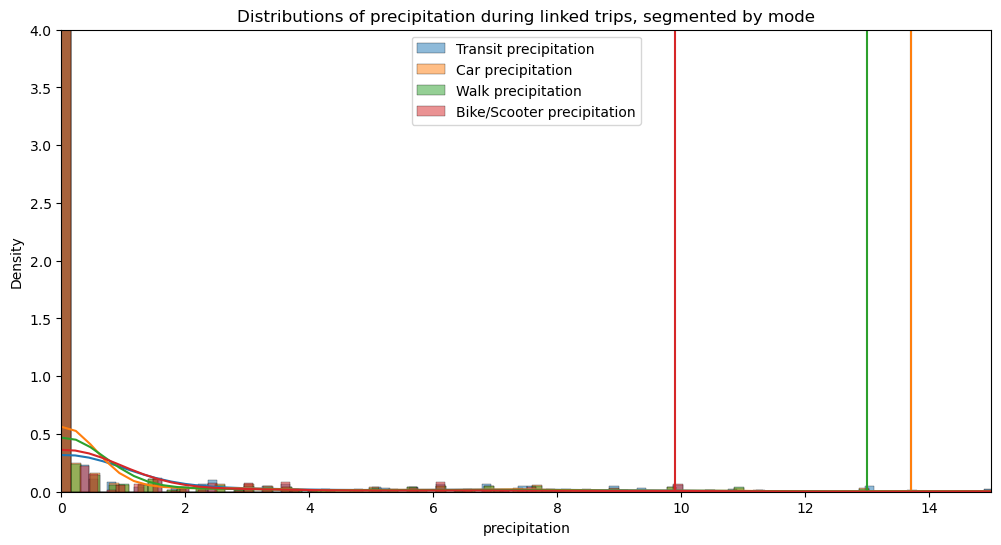

In [48]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','precipitation'), ('Car','precipitation'), ('Walk','precipitation'), ('Bike/Scooter','precipitation')], percentile=0.95)
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
plt.title("Distributions of precipitation during linked trips, segmented by mode")

Summary statistics for these distributions are found below.

In [49]:
#| output: true

show_summaries(df, modes=[('Transit','precipitation'), ('Car','precipitation'), ('Walk','precipitation'), ('Bike/Scooter','precipitation')], percentile= 0.95)

,Transit precipitation,Car precipitation,Walk precipitation,Bike/Scooter precipitation
count,8995.000000,202874.000000,46488.000000,6830.000000
mean,2.275331,2.241605,1.987741,1.642445
std,5.822124,5.996482,5.656384,5.292886
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.800000,0.300000,0.000000
95%,13.700000,13.700000,13.000000,9.900000
max,44.200000,46.500000,46.500000,44.200000


By restricting likely walking/biking shifts to non-rainy days, we reduce the percent of feasible car trips that can likely switch to walking/biking by a fair amount.

In [50]:
#| output: true

df["likely_precipitation_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

df.loc[df["precipitation"] != 0, 'likely_walk_shift'] = False
df.loc[df["precipitation"] != 0, 'likely_precipitation_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  23.907449944300403  percent of car trips could shift to walking.
After constraint  15.925155515245917  percent of car trips could shift to walking.


In [51]:
#| output: true

df["likely_precipitation_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["precipitation"] != 0, 'likely_bike_shift'] = False
df.loc[df["precipitation"] != 0, 'likely_precipitation_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  9.733134852174256  percent of car trips could shift to biking.
After constraint  6.465589479184124  percent of car trips could shift to biking.


## 4. Temperature > X degrees

A tangential topic to rainfall in the topic of likely walk/bike shifts is temperature. As with rainfall, the modes of walking/biking are far more susceptible to temperature than car/transit trips are, making it another consideration for whether a trip shift is likely.

Here, we consider a bike/walk trip likely if it can be done in 12 degrees Celsius or above.

A distribution of average temperatures over the day a linked trip occurred on segmented by mode can be seen below. As with duration difference, we flip the percentile for a more meaningful analysis. Also observe that biking/walking trips tend to occur in higher temperatures than transit/car, reflecting the reasoning discussed earlier.

Text(0.5, 1.0, 'Distributions of temperature during linked trips, segmented by mode')

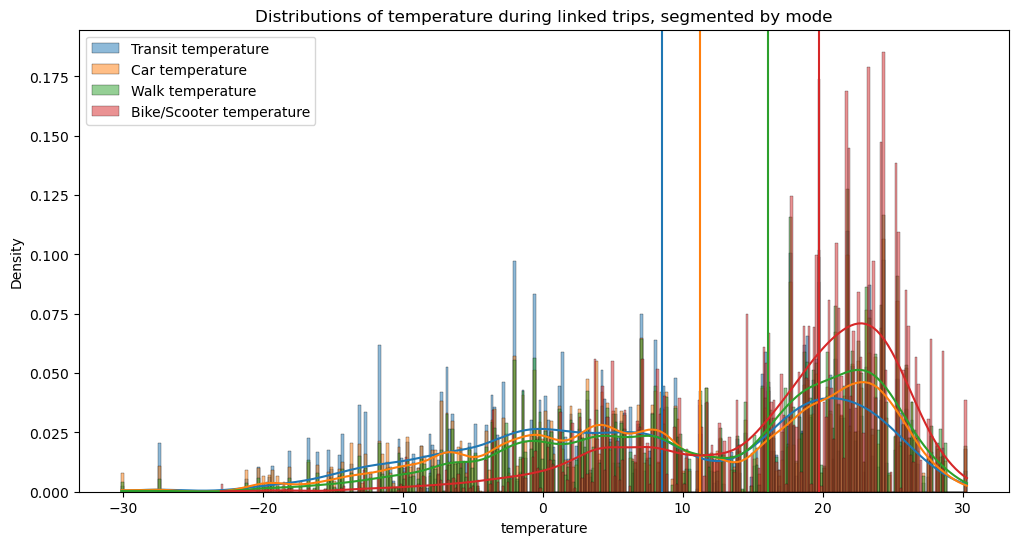

In [52]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','temperature'), ('Car','temperature'), ('Walk','temperature'), ('Bike/Scooter','temperature')], percentile=1-MAX_PROBABLE_DIST_PCT)
plt.title("Distributions of temperature during linked trips, segmented by mode")

The summary statistics for this graph can be found below.

In [53]:
#| output: true

show_summaries(df, modes=[('Transit','temperature'), ('Car','temperature'), ('Walk','temperature'), ('Bike/Scooter','temperature')], percentile= 0.95)

,Transit temperature,Car temperature,Walk temperature,Bike/Scooter temperature
count,8995.000000,202874.000000,46488.000000,6830.000000
mean,8.632407,10.059736,12.173748,17.028624
std,12.542533,12.497394,11.628928,8.938064
min,-30.100000,-30.100000,-30.100000,-23.000000
25%,-0.800000,0.400000,3.300000,12.100000
50%,8.500000,11.200000,16.100000,19.700000
75%,19.700000,21.400000,21.800000,23.400000
95%,25.400000,26.000000,26.100000,26.800000
max,30.300000,30.300000,30.300000,30.300000


When applying this temperature restrictions, a non-insignifciant percent of car trips can no longer liekely switch to biking/walking.

In [54]:
#| output: true

df["likely_temperature_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

df.loc[df["temperature"] < 12, 'likely_walk_shift'] = False
df.loc[df["temperature"] < 12, 'likely_temperature_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  15.925155515245917  percent of car trips could shift to walking.
After constraint  7.29615426323728  percent of car trips could shift to walking.


In [55]:
#| output: true

df["likely_temperature_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["temperature"] < 12, 'likely_bike_shift'] = False
df.loc[df["temperature"] < 12, 'likely_temperature_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  6.465589479184124  percent of car trips could shift to biking.
After constraint  2.978203219732445  percent of car trips could shift to biking.


## 5. Trip occurs in daylight hours

Yet another walking/biking specific likelihood indicator is whether it occurred in daylight hours. Given the more exposed nature of these modes, it may not be ideal for a person embarking on such a mode to do so during daylight hours. As such, we consider a trip likely only if it began (had departure) in daylight hours. 

In [56]:
df["datetime"] = df["travel_date"].apply(lambda x: dt.strptime(x, r"%Y-%m-%d"))
df["datetime"] = df["datetime"].astype('M8[D]').astype('O') # somehow converts datetime64[ns] into datetime

In [57]:
central = pytz.timezone("US/Central")
df[["sunrise", "sunset"]] = pd.DataFrame(get_times(df['datetime'], df["o_lon"], df["o_lat"]))[["sunrise", "sunset"]].applymap(lambda x: x.astimezone(central)) # parsed as utc, convert to central

c:\Users\yianz\miniconda3\envs\vmtmodeenv\lib\site-packages\suncalc\suncalc.py:84: FutureWarning: The behavior of .astype from datetime64[ns] to int32 is deprecated. In a future version, this astype will return exactly the specified dtype instead of int64, and will raise if that conversion overflows.
  return np.array(pd.to_datetime(date).astype(int) / 10 ** 6)


In [58]:
# get standardized sunrise_time/sunset_time to allow for direct string comparison 
df["sunrise_time"] = df["sunrise"].dt.hour.astype(str).str.zfill(2) + ":" + df["sunrise"].dt.minute.astype(str).str.zfill(2) + ":" + df["sunrise"].dt.second.astype(str).str.zfill(2)
df["sunset_time"] = df["sunset"].dt.hour.astype(str).str.zfill(2) + ":" + df["sunset"].dt.minute.astype(str).str.zfill(2) + ":" + df["sunset"].dt.second.astype(str).str.zfill(2)

In [59]:
# string comparison works since 13 > 03--alphabetical is chronological
df["during_daylight"] = (df["depart_time"] > df["sunrise_time"]) & (df["arrive_time"] < df["sunset_time"])

As can be seen here, in general, walking/biking trips occur more often at daylight than not, but the difference isn't that substantial. Nevertheless, we will still apply this restriction and potentially loosen it later.

Text(0.5, 1.0, '% of trips in each mode that occurred during/not during daylight')

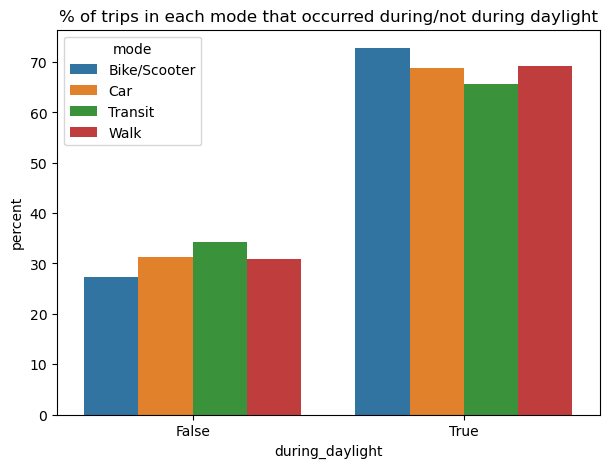

In [60]:
#| output: true

# bar plot of the % of trips in a given mode that occur during/not during daylight side by side for all modes
# less relative walk/transit trips at night/more at day
# more relative transit/car trips at night, more at day
plot_multi_barplot(df, "during_daylight", "mode")
plt.title("% of trips in each mode that occurred during/not during daylight")

With this restrictions, we restrict a small percentage of the remaining car trips that can likely switch to biking/walking. 

In [61]:
#| output: true

df["likely_daylight_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

df.loc[~df["during_daylight"], 'likely_walk_shift'] = False
df.loc[~df["during_daylight"], 'likely_daylight_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  7.29615426323728  percent of car trips could shift to walking.
After constraint  5.744452221575953  percent of car trips could shift to walking.


In [62]:
#| output: true

df["likely_daylight_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[~df["during_daylight"], 'likely_bike_shift'] = False
df.loc[~df["during_daylight"], 'likely_daylight_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  2.978203219732445  percent of car trips could shift to biking.
After constraint  2.3196663939193787  percent of car trips could shift to biking.


## 6. Number of transfers > X transfers

Transfers are a very costly and inconvenient part of going on transit, which makes it a good indicator for whether a trip can likely switch to transit. Here, we only consider transit trips that require 0 transfers likely.

As seen in the feasibility analysis, the rerouted transfer coutns are reasonably accurate when compared to the approximated transfer counts, although they do display substantially less variability.

Text(0.5, 1.0, 'Re-routed transfer counts for canonical transit trips')

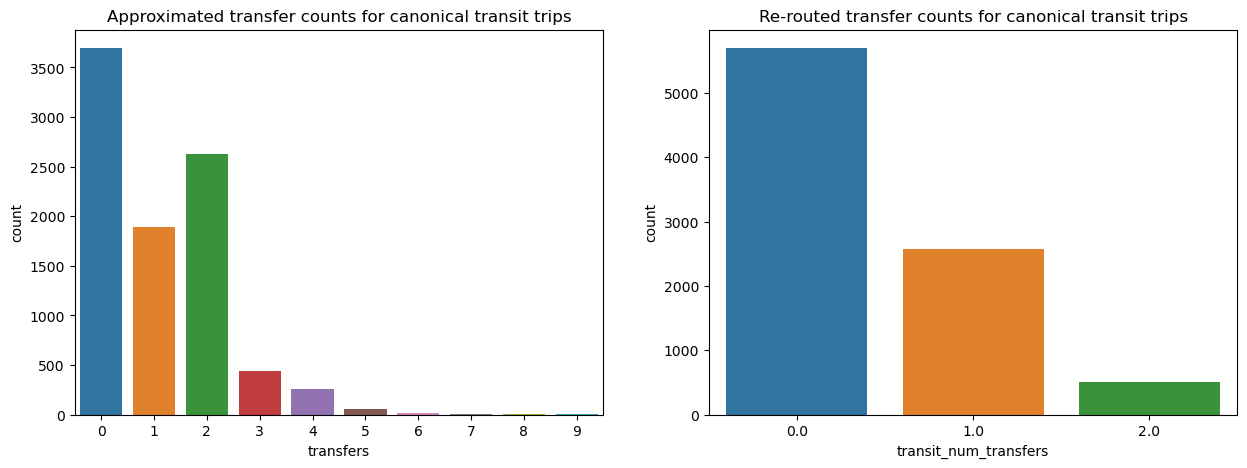

In [63]:
#| output: true
# check how the calculated transfer count for car trips compare to the observed transfer count for transit trips
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x="transfers", data=df[df["mode"] == "Transit"], ax=ax[0])
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Transit"], ax=ax[1])
ax[0].set_title("Approximated transfer counts for canonical transit trips")
ax[1].set_title("Re-routed transfer counts for canonical transit trips")

We thus use the rerouted transfer counts to directly compare the transfer distributions for observed car and transit trips, which is seen below. Observe that the number of transfers for observed transit trips are more left-skewed than those for observed car trips, showing that transfer number is indeed an important indicator for trip likelihood (this could be a reflection of rerouting restrictions, though).

Text(0.5, 1.0, 'Re-routed optimized transfer counts for canonical car trips')

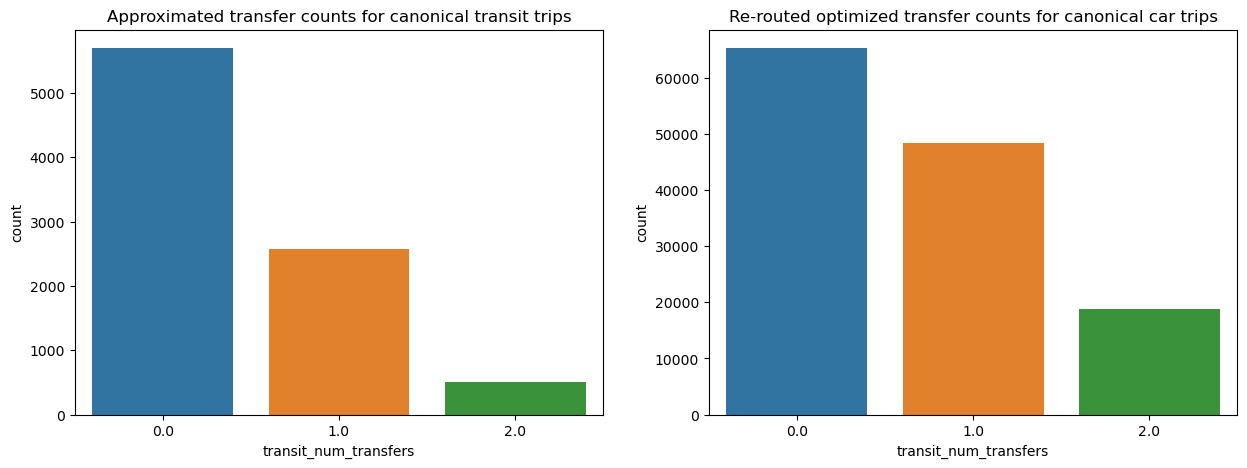

In [64]:
#| output: true

# compare observed distribution of transfer count to calculated distribution of transfer count 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Transit"], ax=ax[0])
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Car"], ax=ax[1])
# it seems the calculated transfer count distribution seems to have a hard cap at 2 and varies less than the observed count
# we will use the observed transfers as a cutoff--max 3 transfers for feasibility
ax[0].set_title("Approximated transfer counts for canonical transit trips")
ax[1].set_title("Re-routed optimized transfer counts for canonical car trips")

By limiting likely transit trip shifts to those that can be done in zero transfers, we cut down the percent of car trips that can shift to transit substantially.

In [65]:
#| output: true

df["likely_transfer_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

df.loc[df["transit_num_transfers"] > MAX_PROBABLE_TRANFERS, 'likely_transit_shift'] = False
df.loc[df["transit_num_transfers"] > MAX_PROBABLE_TRANFERS, 'likely_transfer_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")

Before constraint  57.637745595788516  percent of car trips could shift to transit.
After constraint  53.112276585466844  percent of car trips could shift to transit.


## 7. Purpose

Some trip purposes cannot be switched from modes that facilitate them better--e.g., car for shopping trips. As such, we will consider any car trip that involves escorting someone or shopping to be not likely to switch to an alternative mode. 

In [66]:
# merging some closely related categories
df["purpose_cleaned"] = df["d_purpose_category"]
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["School", "School-related"]), "School", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Work", "Work-related"]), "Work", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Errand/Other", "Errand"]), "Errand", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Shop", "Shopping"]), "Shop", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Missing: Non-response", "Missing: Skip logic", "Not imputable"]), "Missing", df["purpose_cleaned"])

Below, we can see the distribution of all the cleaned purposes in the TBI data. As can be seen, the most popular trip purposes are the fundamental, primary ones like going to work or returnign home.

Text(0.5, 1.0, 'Count plot of the cleaned destination purposes in the TBI data')

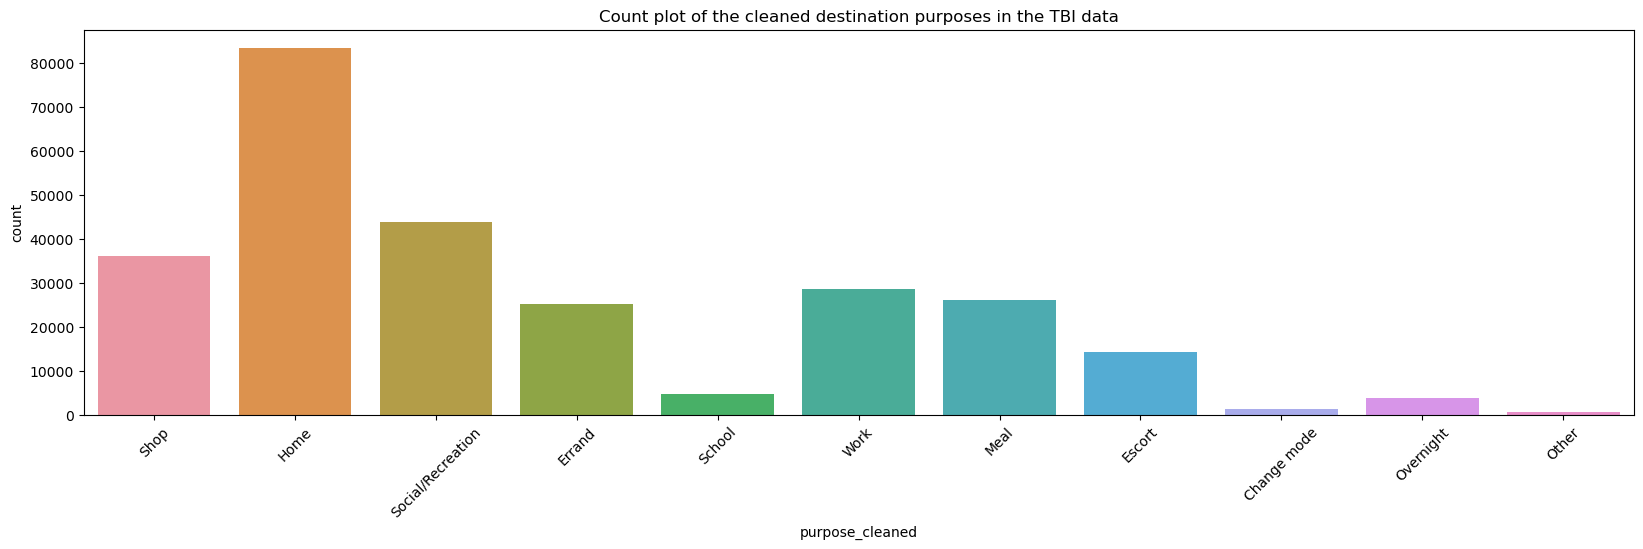

In [67]:
#| output: true

# overall distribution
fig, ax = plt.subplots(figsize=(20, 5))
sns.countplot(x="purpose_cleaned", data=df[df["purpose_cleaned"] != "Missing"], ax=ax)
plt.xticks(rotation=45)
plt.title("Count plot of the cleaned destination purposes in the TBI data")

Below, we can see the same graph segmented by graph. As alluded to earlier, some purposes are done with certain modes at a much higher frequency than others--e.g., cars with escorting tasks. 

Text(0.5, 1.0, 'Count plot of the cleaneddestination purposes in the TBI data, segmented by mode')

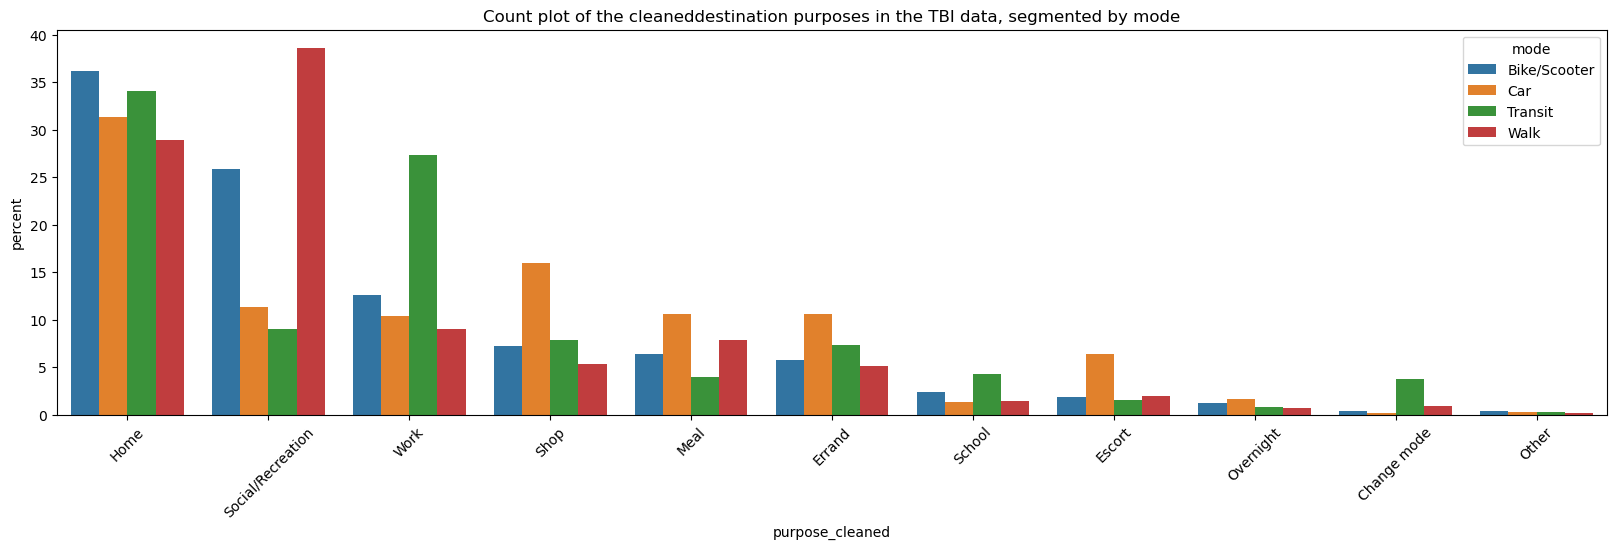

In [68]:
#| output: true

# purpose segmented by mode -- % of all mode trips in each purpose category
# notable features: social/recreation is predominantly walking, errands/shopping/escorts are mostly car
fig, ax = plot_multi_barplot(df[df["purpose_cleaned"] != "Missing"], "purpose_cleaned", "mode", figsize=(20, 5))
plt.xticks(rotation=45)
plt.title("Count plot of the cleaneddestination purposes in the TBI data, segmented by mode")

With this restriction, we reduce the percentage of trips that can likely shift to alternative modes once again.

In [69]:
#| output: true

df["likely_purpose_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_bike_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  2.3196663939193787  percent of car trips could shift to biking.
After constraint  1.8642112838510603  percent of car trips could shift to biking.


In [70]:
#| output: true

df["likely_purpose_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_walk_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")

Before constraint  5.744452221575953  percent of car trips could shift to walking.
After constraint  4.103532241686959  percent of car trips could shift to walking.


In [71]:
#| output: true

df["likely_purpose_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_transit_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")

Before constraint  53.112276585466844  percent of car trips could shift to transit.
After constraint  40.18208346067017  percent of car trips could shift to transit.


## 7. Distance on LTS 3 + 4 > X meters

In the feasibility analysis, we had a similar constraint on the % of LTS, but now, we impose a stricter restriction on high stress distance--specifically 0 (by default).

In [72]:
df["high_stress_biking_distance"] = df["bike_distance_meters_3"] + df["bike_distance_meters_4"]
df["high_stress_biking_pct"] = df["high_stress_biking_distance"] / df["bike_distance_meters"]

The comparison of the distribution between bike/car lts distance can be seen below. This reflects what was seen in the feasibilty analysis, with bike trips tending to have lower absolute lts distances.

(0.0, 500.0)

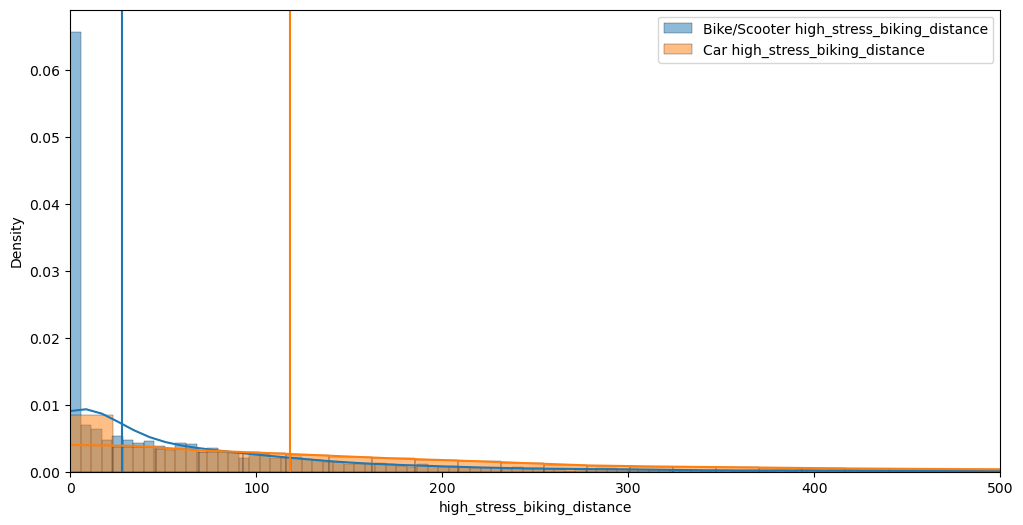

In [73]:
#| output: true

# comparing distribution of amount of high stress biking distance existing biking trips have to go through to that potentially switching car trips would have to travel through
# anything to the left of the blue line is within the 95th percentile of high stress biking distance for existing bikers and is thus an upper bound
fig, ax = plot_mode_density(df, modes=[("Bike/Scooter", "high_stress_biking_distance"), ("Car", "high_stress_biking_distance")], percentile=MAX_HIGH_LTS_DIST_BIKE_PCT)
ax.set_xlim(left=0, right=500)
# we will use 250m as a lower cutoff

The summary statistics can be found below.

In [74]:
#| output: true

show_summaries(df, modes=[("Bike/Scooter", "high_stress_biking_distance"), ("Car", "high_stress_biking_distance")], percentile= MAX_HIGH_LTS_DIST_BIKE_PCT)

,Bike/Scooter high_stress_biking_distance,Car high_stress_biking_distance
count,6830.000000,202874.000000
mean,73.314410,195.394124
std,127.041574,244.400407
min,0.000000,0.000000
25%,0.000000,37.907174
50%,27.639338,117.981536
75%,96.462765,249.133139
max,1696.548173,6946.157909


In [75]:
#| output: true

df["likely_highlts_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

df.loc[df["high_stress_biking_distance"] > MAX_HIGH_LTS_DIST_BIKE, 'likely_bike_shift'] = False
df.loc[df["high_stress_biking_distance"] > MAX_HIGH_LTS_DIST_BIKE, 'likely_highlts_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  1.8642112838510603  percent of car trips could shift to biking.
After constraint  0.750712264755464  percent of car trips could shift to biking.


# Overall statistics

Similar to the feasibility analysis, we can report overall statistics/metrics for likely mode shifts.

In [76]:
#| echo: true
df["likely_shift"] = df["likely_transit_shift"] | df["likely_walk_shift"] | df["likely_bike_shift"]

In [77]:
#| output: true
print("Percent of car trips that can likely switch to an alterantive mode (bike, walk, or transit):")
print(df[df["mode"] == "Car"]["likely_shift"].sum() / len(df[df["mode"] == "Car"]))
print()

Percent of car trips that can likely switch to an alterantive mode (bike, walk, or transit):
0.40660212742884744



In [78]:
#| output: true
print("Total number of person trips on car before applying likely mode shift:")
print(len(df[df["mode"] == "Car"]))
print("Total number of person trips on car after applying likely mode shift:")
print(len(df[(df["mode"] == "Car") & (~df["likely_shift"])]))
print()

Total number of person trips on car before applying likely mode shift:
202874
Total number of person trips on car after applying likely mode shift:
120385



In [79]:
#| output: true
print("Total number of vehicle trips on car before applying likely mode shift:")
print(df[df["mode"] == "Car"]["vehicle_trips"].sum())
print("Total number of vehicle trips on car after applying likely mode shift:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])]["vehicle_trips"].sum())
print()

Total number of vehicle trips on car before applying likely mode shift:
147360.8867965368
Total number of vehicle trips on car after applying likely mode shift:
88787.70692640691



In [80]:
#| output: true
print("Total VMT before applying likely mode shift:")
print(df[df["mode"] == "Car"]["vmt"].sum())
print("Total VMT after applying likely mode shift:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])]["vmt"].sum())
print()

Total VMT before applying likely mode shift:
570998.9936109858
Total VMT after applying likely mode shift:
438563.66458554805



In [81]:
COLD_START_THRESHOLD = 15

def get_num_cold_starts(chunk):
    leg_starts = chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values
    ref = leg_starts[0]
    # start times, starting by 0 and accounting for midnight wraparound with the mod function, for each leg of the complete tour
    leg_starts = [(x - ref) % 1440 for x in chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values]
    leg_durations = chunk["duration"].values
    # calculate end times relative to the start times using the duration category
    leg_ends = [(x + y) for (x, y) in zip(leg_starts, leg_durations)]
    modes = chunk["mode"].values
    
    cold_starts = 0
    prev_end = -1
    # iterate over all trips in a complete tour
    for i in range(len(leg_starts)):
        # if the current leg mode i car
        if modes[i] == "Car":
            # if there wasn't a previous or the difference between the end of the last car trip and the beginning of this car trip is more than 15 minutes, it is a cold start
            if prev_end == -1 or leg_starts[i] - leg_ends[i] > COLD_START_THRESHOLD:
                cold_starts += 1
            # update previous end of car trip
            prev_end = leg_ends[i]
    return cold_starts            

In [82]:
#| output: true
print("Number of cold starts before applying likely mode shifts:")
print(df[df["mode"] == "Car"].groupby(["wave", "person_id", "travel_date"]).apply(lambda x: get_num_cold_starts(x)).sum())
print("Number of cold starts after applying feasible mode shifts:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])].groupby(["wave", "person_id", "travel_date"]).apply(lambda x: get_num_cold_starts(x)).sum())
print()

Number of cold starts before applying likely mode shifts:
66719
Number of cold starts after applying feasible mode shifts:
49030



Exporting results with likely flags added for further analysis:

In [83]:
#| echo: true
df.to_csv(data_dir + "/data_processed/likely_shifts.csv")

In [ ]:
# make it configurable -- give it a set of parameters and have it spit out graphs/analysis
